In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import pairwise_kernels
from kernel import rbf, laplace
from experiments import imm_experiments, refine_imm
from utils import load_dataset, plot_result, plot_metric

rng = np.random.default_rng()

gammas = np.array([0.01, 0.05, 0.1, 0.5, 1, 5, 10])

In [2]:
### Pathbased
X, y_true = load_dataset("Pathbased")

gammas = [0.05] # set optimum for a quick run
imm_path1, imm_path2 = imm_experiments(X, y_true, gammas)

--- First k-means
---> Rand Score of k-means: 0.46132893486545035
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0 1 2]
Cluster Label Partioning: [0 1] and [2]
Mistakes: 0
Cut node 0 at Coordinate 1 Threshold 26.125 ---> Mistakes = 0
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0 1]
Cluster Label Partioning: [0] and [1]
Mistakes: 0
--- Check node 1 ---
Node 1 contains cluster labels [2]
... This is already a Leaf
Cut node 0 at Coordinate 0 Threshold 18.625 ---> Mistakes = 0
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0]
... This is already a Leaf
--- Check node 1 ---
Node 1 contains cluster labels [2]
... This is already a Leaf
--- Check node 2 ---
Node 2 contains cluster labels [1]
... This is already a Leaf
+++ IMM has finished +++
---> Rand Score of linear IMM: 0.46132893486545035
--- Now to kernels. Find kernel and gamma ---
Test Gamma = 0.05
We choose the <function rbf at 0x10e9c3f60> kernel with gamma = 0.05
-

In [3]:
y_kkm = imm_path2['y_kkm']
gamma = imm_path1['best_gamma']

if imm_path1['best_kernel'] == 0:
    Kmat = pairwise_kernels(X, metric=rbf, gamma=gamma)
    if imm_path1['price_taylor_imm_on_kkm'] < imm_path1['price_kmat_imm_on_kkm']:
        print('Gaussian Taylor')
        y_imm = imm_path2['y_taylor_imm_on_kkm']
        price_imm = imm_path1['price_taylor_imm_on_kkm']
        rand_imm = imm_path1['rand_taylor_imm_on_kkm']
    else:
        print('Gaussian Kernel Matrix')
        y_imm = imm_path2['y_kmat_imm_on_kkm']
        price_imm = imm_path1['price_kmat_imm_on_kkm']
        rand_imm = imm_path1['rand_kmat_imm_on_kkm']
else:
    print('Laplace Kernel Matrix')
    Kmat = pairwise_kernels(X, metric=laplace, gamma=gamma)
    y_imm = imm_path2['y_kmat_imm_on_kkm']
    price_imm = imm_path1['price_kmat_imm_on_kkm']
    rand_imm = imm_path1['rand_kmat_imm_on_kkm']

refine_path1, refine_path2 = refine_imm(X, y_true, y_kkm, y_imm, Kmat, max_leaves = 6)

Gaussian Kernel Matrix
Kernel ExKMC
+++ Currently, we have 3 node(s). Let us find a new cut! +++
--- Check node 0 ---
Number of points at this node: 77
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
---> Delta =  3.0
--- Check node 1 ---
Number of points at this node: 112
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
---> Delta =  20.0
--- Check node 2 ---
Number of points at this node: 111
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
---> Delta =  22.0
--- NEW CUT --- ... at node 2 ... at Coordinate 1 ... at Thresholds 11.75 21.5
Node left: 89
Node right: 22
+++ Currently, we have 4 node(s). Let us find a new cut! +++
--- Check node 0 ---
Number of points at this node: 77
Available info at this node: {'best_delta': np.float64(3.0), 'best_i': np.int64(0), 'best_theta1': np.float64(16.6), 'best_theta2': np.float64(17.5)}
---

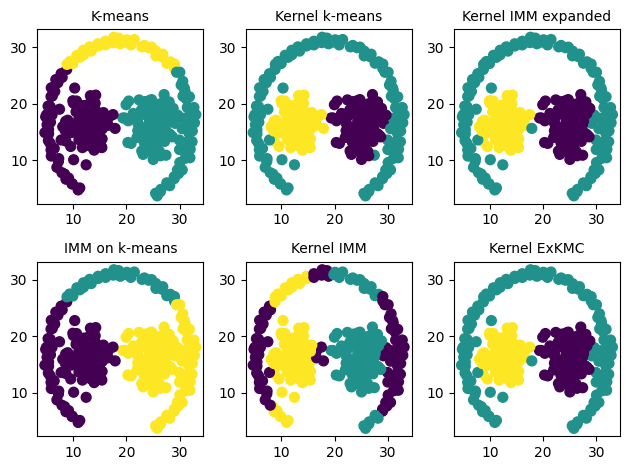

In [4]:
### Make a plot
y_kmeans = imm_path2['y_kmeans']
y_kmeans_imm = imm_path2['y_kmeans_imm']
y_exkmc = refine_path2['y_exkmc']
y_expand = refine_path2['y_expand']

plot_result(X, y_kmeans, y_kkm, y_expand, y_kmeans_imm, y_imm, y_exkmc)

In [5]:
print(imm_path1, refine_path1)

{'rand_kmeans': 0.46132893486545035, 'rand_imm': 0.46132893486545035, 'best_kernel': np.int64(0), 'best_gamma': 0.05, 'rand_kkm': 0.9193663398335051, 'rand_taylor_imm_on_kkm': 0.4545233406078077, 'price_taylor_imm_on_kkm': np.float64(1.0719338880137301), 'rand_kmat_imm_on_kkm': 0.6144936690069644, 'price_kmat_imm_on_kkm': np.float64(1.0664520967302742), 'threshold_cuts_taylor': array([[0.00000000e+00, 0.00000000e+00, 1.33238832e-08],
       [1.00000000e+00, 0.00000000e+00, 2.87579594e-02]]), 'threshold_cuts_kmat': array([[  0.        , 121.        ,   0.29021985],
       [  0.        ,  40.        ,   0.45838081]])} {'rand_exkmc': 0.939019153867537, 'price_exkmc': np.float64(1.001564409550788), 'rand_expand': 0.939019153867537, 'price_expand': np.float64(1.001564409550788)}


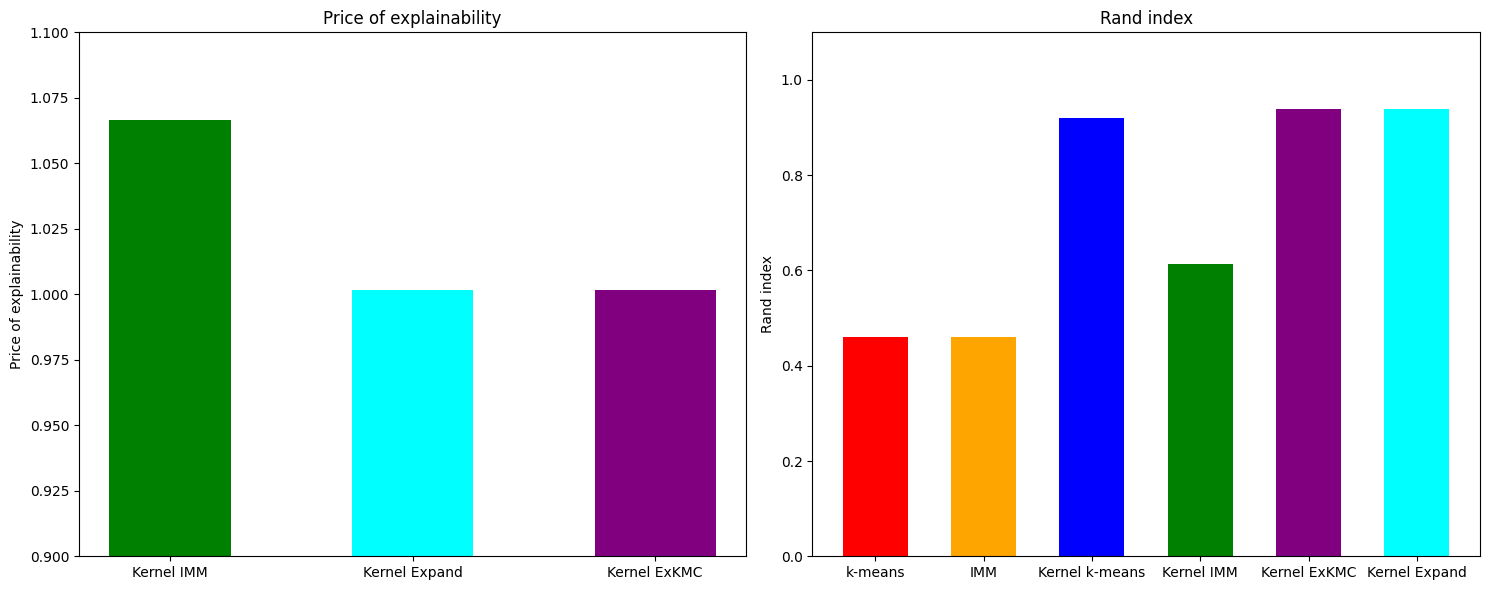

In [6]:
price_values = [price_imm, refine_path1['price_expand'], refine_path1['price_exkmc']]
rand_values = [imm_path1['rand_kmeans'], imm_path1['rand_imm'], imm_path1['rand_kkm'], rand_imm, refine_path1['rand_exkmc'], refine_path1['rand_expand']]
plot_metric(price_values, rand_values)

In [7]:
### Aggregation
X, y_true = load_dataset("Aggregation")

gammas = [0.1]
imm_agg1, imm_agg2 = imm_experiments(X, y_true, gammas)

--- First k-means
---> Rand Score of k-means: 0.7593804191720556
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0 1 2 3 4 5 6]
Cluster Label Partioning: [0 2 3 4 5] and [1 6]
Mistakes: 0
Cut node 0 at Coordinate 0 Threshold 27.0 ---> Mistakes = 0
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0 2 3 4 5]
Cluster Label Partioning: [0 3 5] and [2 4]
Mistakes: 0
--- Check node 1 ---
Node 1 contains cluster labels [1 6]
Cluster Label Partioning: [6] and [1]
Mistakes: 0
Cut node 0 at Coordinate 1 Threshold 15.049999999999999 ---> Mistakes = 0
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0 3 5]
Cluster Label Partioning: [0] and [3 5]
Mistakes: 0
--- Check node 1 ---
Node 1 contains cluster labels [1 6]
Cluster Label Partioning: [6] and [1]
Mistakes: 0
--- Check node 2 ---
Node 2 contains cluster labels [2 4]
Cluster Label Partioning: [2] and [4]
Mistakes: 0
Cut node 0 at Coordinate 0 Threshold 11.2 ---> Mistakes = 0
+++ New C

In [8]:
y_kkm = imm_agg2['y_kkm']
gamma = imm_agg1['best_gamma']

if imm_agg1['best_kernel'] == 0:
    Kmat = pairwise_kernels(X, metric=rbf, gamma=gamma)
    if imm_agg1['price_taylor_imm_on_kkm'] < imm_agg1['price_kmat_imm_on_kkm']:
        print('Gaussian Taylor')
        y_imm = imm_agg2['y_taylor_imm_on_kkm']
        price_imm = imm_agg1['price_taylor_imm_on_kkm']
        rand_imm = imm_agg1['rand_taylor_imm_on_kkm']
    else:
        print('Gaussian Kernel Matrix')
        y_imm = imm_agg2['y_kmat_imm_on_kkm']
        price_imm = imm_agg1['price_kmat_imm_on_kkm']
        rand_imm = imm_agg1['rand_kmat_imm_on_kkm']
else:
    print('Laplace Kernel Matrix')
    Kmat = pairwise_kernels(X, metric=laplace, gamma=gamma)
    y_imm = imm_agg2['y_kmat_imm_on_kkm']
    price_imm = imm_agg1['price_kmat_imm_on_kkm']
    rand_imm = imm_agg1['rand_kmat_imm_on_kkm']

refine_agg1, refine_agg2 = refine_imm(X, y_true, y_kkm, y_imm, Kmat, max_leaves=len(np.unique(y_true))+3)

Laplace Kernel Matrix
Kernel ExKMC
+++ Currently, we have 7 node(s). Let us find a new cut! +++
--- Check node 0 ---
Number of points at this node: 104
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
---> Delta =  0.0
--- Check node 1 ---
Number of points at this node: 139
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
---> Delta =  2.0
--- Check node 2 ---
Number of points at this node: 128
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
---> Delta =  0.0
--- Check node 3 ---
Number of points at this node: 45
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
---> Delta =  0.0
--- Check node 4 ---
Number of points at this node: 170
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
---> Delta =  0.0
--- Check node 5 ---
Number of

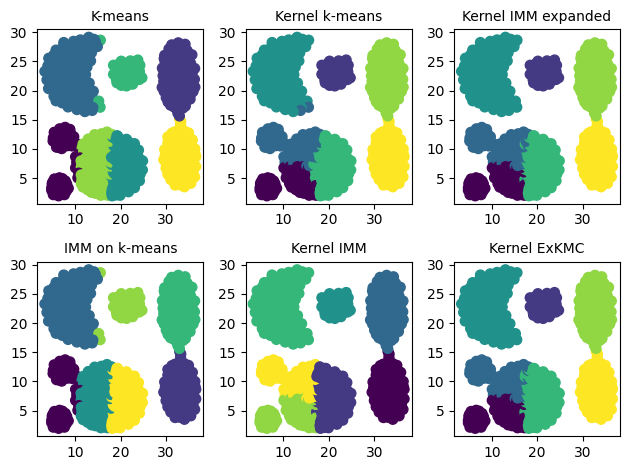

In [9]:
### Make a plot
y_kmeans = imm_agg2['y_kmeans']
y_kmeans_imm = imm_agg2['y_kmeans_imm']
y_exkmc = refine_agg2['y_exkmc']
y_expand = refine_agg2['y_expand']

plot_result(X, y_kmeans, y_kkm, y_expand, y_kmeans_imm, y_imm, y_exkmc)

In [10]:
print(imm_agg1, refine_agg1)

{'rand_kmeans': 0.7593804191720556, 'rand_imm': 0.7597881396919534, 'best_kernel': np.int64(1), 'best_gamma': 0.1, 'rand_kkm': 0.6928827054658984, 'rand_kmat_imm_on_kkm': 0.7030013455241422, 'price_kmat_imm_on_kkm': np.float64(1.001538283719154), 'threshold_cuts_kmat': array([[0.00000000e+00, 0.00000000e+00, 2.75945472e-01],
       [0.00000000e+00, 7.88000000e+02, 2.65886027e-01],
       [1.00000000e+00, 7.88000000e+02, 2.59003153e-01],
       [3.00000000e+00, 2.00000000e+01, 4.70063492e-01],
       [1.00000000e+00, 2.00000000e+01, 5.20743920e-01],
       [5.00000000e+00, 7.88000000e+02, 1.15040404e-01]])} {'rand_exkmc': 0.6996966621084909, 'price_exkmc': np.float64(1.001633455291747), 'rand_expand': 0.6966113944994929, 'price_expand': np.float64(1.0024806744347068)}


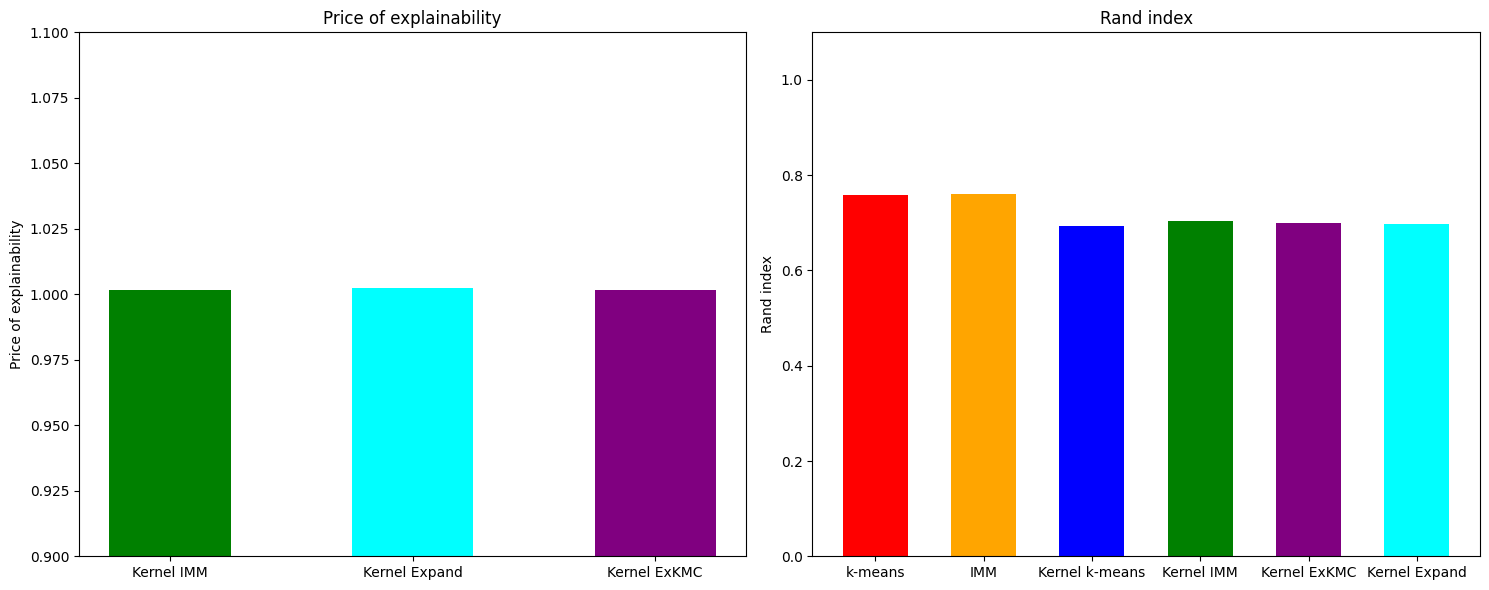

In [11]:
price_values = [price_imm, refine_agg1['price_expand'], refine_agg1['price_exkmc']]
rand_values = [imm_agg1['rand_kmeans'], imm_agg1['rand_imm'], imm_agg1['rand_kkm'], rand_imm, refine_agg1['rand_exkmc'], refine_agg1['rand_expand']]
plot_metric(price_values, rand_values)

In [12]:
### Flame
X, y_true = load_dataset("Flame")

gamma = [0.05]
imm_flame1, imm_flame2 = imm_experiments(X, y_true, gammas)

--- First k-means
---> Rand Score of k-means: 0.4534129232216995
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0 1]
Cluster Label Partioning: [1] and [0]
Mistakes: 40
Cut node 0 at Coordinate 1 Threshold 21.275 ---> Mistakes = 40
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [1]
... This is already a Leaf
--- Check node 1 ---
Node 1 contains cluster labels [0]
... This is already a Leaf
+++ IMM has finished +++
---> Rand Score of linear IMM: 0.4534129232216995
--- Now to kernels. Find kernel and gamma ---
Test Gamma = 0.1
We choose the <function rbf at 0x10e9c3f60> kernel with gamma = 0.1
--- Run kernel k-means ---
---> Rand Score: 0.9013709892780234
Run Gaussian Taylor IMM on kernel k-means
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0 1]
Cluster Label Partioning: [1] and [0]
Mistakes: 28
Cut node 0 at Coordinate 5 Threshold 1.5171418170747711e-21 ---> Mistakes = 28
+++ New Cut +++
--- Check node 0 ---
Node 0 contai

In [13]:
y_kkm = imm_flame2['y_kkm']
gamma = imm_flame1['best_gamma']

if imm_flame1['best_kernel'] == 0:
    Kmat = pairwise_kernels(X, metric=rbf, gamma=gamma)
    if imm_flame1['price_taylor_imm_on_kkm'] < imm_flame1['price_kmat_imm_on_kkm']:
        print('Gaussian Taylor')
        y_imm = imm_flame2['y_taylor_imm_on_kkm']
        price_imm = imm_flame1['price_taylor_imm_on_kkm']
        rand_imm = imm_flame1['rand_taylor_imm_on_kkm']
    else:
        print('Gaussian Kernel Matrix')
        y_imm = imm_flame2['y_kmat_imm_on_kkm']
        price_imm = imm_flame1['price_kmat_imm_on_kkm']
        rand_imm = imm_flame1['rand_kmat_imm_on_kkm']
else:
    print('Laplace Kernel Matrix')
    Kmat = pairwise_kernels(X, metric=laplace, gamma=gamma)
    y_imm = imm_flame2['y_kmat_imm_on_kkm']
    price_imm = imm_flame1['price_kmat_imm_on_kkm']
    rand_imm = imm_flame1['rand_kmat_imm_on_kkm']

refine_flame1, refine_flame2 = refine_imm(X, y_true, y_kkm, y_imm, Kmat, max_leaves = 4)

Gaussian Taylor
Kernel ExKMC
+++ Currently, we have 2 node(s). Let us find a new cut! +++
--- Check node 0 ---
Number of points at this node: 99
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
---> Delta =  23.0
--- Check node 1 ---
Number of points at this node: 141
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
---> Delta =  1.0
--- NEW CUT --- ... at node 0 ... at Coordinate 0 ... at Thresholds 3.75 10.55
Node left: 76
Node right: 23
+++ Currently, we have 3 node(s). Let us find a new cut! +++
--- Check node 0 ---
Number of points at this node: 76
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
---> Delta =  0.0
--- Check node 1 ---
Number of points at this node: 141
Available info at this node: {'best_delta': np.float64(1.0), 'best_i': np.int64(1), 'best_theta1': np.float64(21.6), 'best_theta2': np.float64(21.75)}
---> Delta

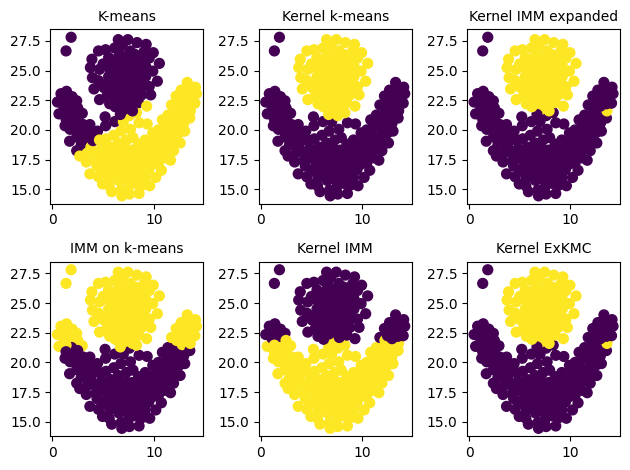

In [14]:
### Make a plot
y_kmeans = imm_flame2['y_kmeans']
y_kmeans_imm = imm_flame2['y_kmeans_imm']
y_exkmc = refine_flame2['y_exkmc']
y_expand = refine_flame2['y_expand']

plot_result(X, y_kmeans, y_kkm, y_expand, y_kmeans_imm, y_imm, y_exkmc)

In [15]:
print(imm_flame1, refine_flame1)

{'rand_kmeans': 0.4534129232216995, 'rand_imm': 0.5235448001414824, 'best_kernel': np.int64(0), 'best_gamma': 0.1, 'rand_kkm': 0.9013709892780234, 'rand_taylor_imm_on_kkm': 0.5598302623403744, 'price_taylor_imm_on_kkm': np.float64(1.0225573806056691), 'rand_kmat_imm_on_kkm': 0.5947850347623862, 'price_kmat_imm_on_kkm': np.float64(1.0270845352130797), 'threshold_cuts_taylor': array([[0.00000000e+00, 5.00000000e+00, 1.51714182e-21]]), 'threshold_cuts_kmat': array([[  0.        , 435.        ,   0.56889779]])} {'rand_exkmc': 0.8382978401701082, 'price_exkmc': np.float64(1.0041921388699762), 'rand_expand': 0.8382978401701082, 'price_expand': np.float64(1.0041921388699762)}


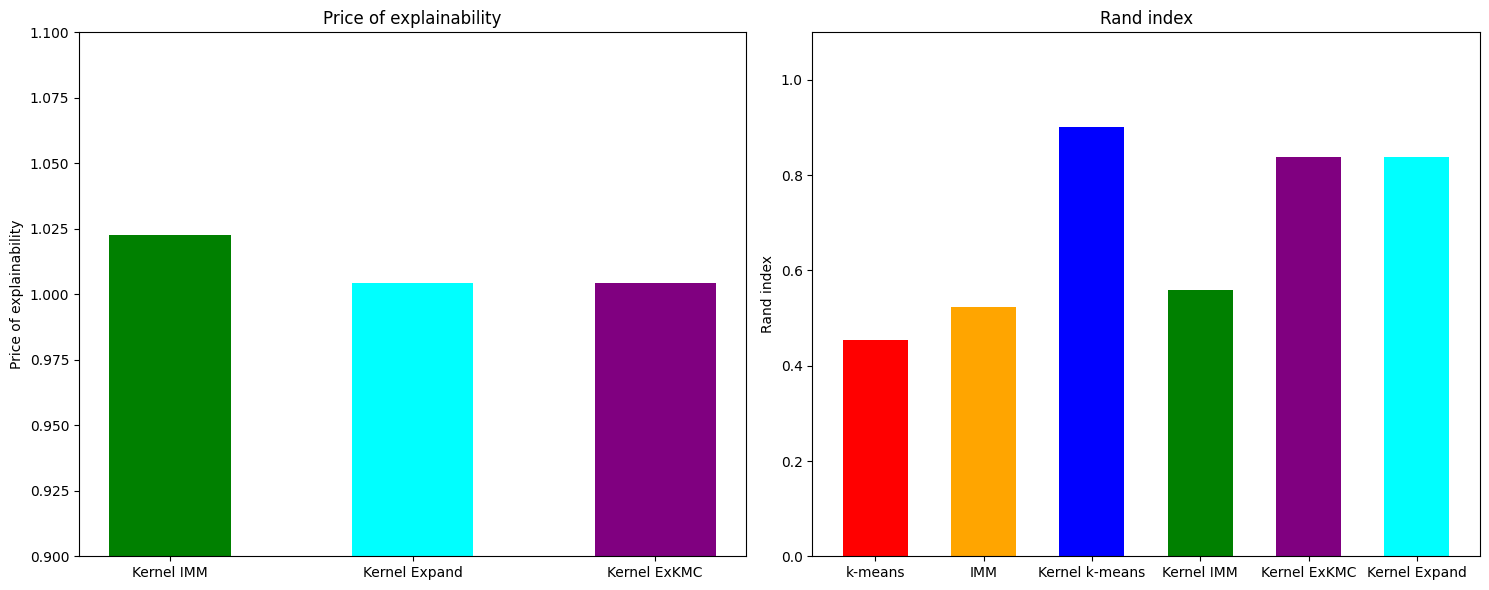

In [16]:
price_values = [price_imm, refine_flame1['price_expand'], refine_flame1['price_exkmc']]
rand_values = [imm_flame1['rand_kmeans'], imm_flame1['rand_imm'], imm_flame1['rand_kkm'], rand_imm, refine_flame1['rand_exkmc'], refine_flame1['rand_expand']]
plot_metric(price_values, rand_values)

In [17]:
X, y_true = load_dataset("Iris")

gammas = [1]
imm_iris1, imm_iris2 = imm_experiments(X, y_true, gammas)

--- First k-means
---> Rand Score of k-means: 0.7302382722834697
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0 1 2]
Cluster Label Partioning: [0] and [1 2]
Mistakes: 0
Cut node 0 at Coordinate 2 Threshold 2.45 ---> Mistakes = 0
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0]
... This is already a Leaf
--- Check node 1 ---
Node 1 contains cluster labels [1 2]
Cluster Label Partioning: [1] and [2]
Mistakes: 4
Cut node 1 at Coordinate 2 Threshold 5.15 ---> Mistakes = 4
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0]
... This is already a Leaf
--- Check node 1 ---
Node 1 contains cluster labels [1]
... This is already a Leaf
--- Check node 2 ---
Node 2 contains cluster labels [2]
... This is already a Leaf
+++ IMM has finished +++
---> Rand Score of linear IMM: 0.7302382722834697
--- Now to kernels. Find kernel and gamma ---
Test Gamma = 1
We choose the <function rbf at 0x10e9c3f60> kernel with gamma = 1
--- Run kerne

In [18]:
y_kkm = imm_iris2['y_kkm']
gamma = imm_iris1['best_gamma']

if imm_iris1['best_kernel'] == 0:
    Kmat = pairwise_kernels(X, metric=rbf, gamma=gamma)
    if imm_iris1['price_taylor_imm_on_kkm'] < imm_iris1['price_kmat_imm_on_kkm']:
        print('Gaussian Taylor')
        y_imm = imm_iris2['y_taylor_imm_on_kkm']
        price_imm = imm_iris1['price_taylor_imm_on_kkm']
        rand_imm = imm_iris1['rand_taylor_imm_on_kkm']
    else:
        print('Gaussian Kernel Matrix')
        y_imm = imm_iris2['y_kmat_imm_on_kkm']
        price_imm = imm_iris1['price_kmat_imm_on_kkm']
        rand_imm = imm_iris1['rand_kmat_imm_on_kkm']
else:
    print('Laplace Kernel Matrix')
    Kmat = pairwise_kernels(X, metric=laplace, gamma=gamma)
    y_imm = imm_iris2['y_kmat_imm_on_kkm']
    price_imm = imm_iris1['price_kmat_imm_on_kkm']
    rand_imm = imm_iris1['rand_kmat_imm_on_kkm']    

refine_iris1, refine_iris2 = refine_imm(X, y_true, y_kkm, y_imm, Kmat, max_leaves = 6)

Gaussian Kernel Matrix
Kernel ExKMC
+++ Currently, we have 3 node(s). Let us find a new cut! +++
--- Check node 0 ---
Number of points at this node: 34
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
Check Coordinate 2
Check Coordinate 3
---> Delta =  0.0
--- Check node 1 ---
Number of points at this node: 50
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
Check Coordinate 2
Check Coordinate 3
---> Delta =  0.0
--- Check node 2 ---
Number of points at this node: 66
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
Check Coordinate 2
Check Coordinate 3
---> Delta =  2.0
--- NEW CUT --- ... at node 2 ... at Coordinate 3 ... at Thresholds 1.0 2.0
Node left: 64
Node right: 2
+++ Currently, we have 4 node(s). Let us find a new cut! +++
--- Check node 0 ---
Number of points at this node: 34
Available info at this node: {'best_delta': np.

In [19]:
print(imm_iris1, refine_iris1)

{'rand_kmeans': 0.7302382722834697, 'rand_imm': 0.7322981167185344, 'best_kernel': np.int64(0), 'best_gamma': 1, 'rand_kkm': 0.7436826319432358, 'rand_taylor_imm_on_kkm': 0.7322981167185344, 'price_taylor_imm_on_kkm': np.float64(1.0112196029171194), 'rand_kmat_imm_on_kkm': 0.7322981167185344, 'price_kmat_imm_on_kkm': np.float64(1.0112196029171194), 'threshold_cuts_taylor': array([[0.00000000e+00, 1.00000000e+01, 1.35876283e-02],
       [0.00000000e+00, 1.10000000e+01, 2.48812580e-11]]), 'threshold_cuts_kmat': array([[0.00000000e+00, 3.00000000e+02, 4.28052762e-01],
       [0.00000000e+00, 3.00000000e+02, 8.34630960e-07]])} {'rand_exkmc': 0.7591987071071522, 'price_exkmc': np.float64(1.0047888429772125), 'rand_expand': 0.7591987071071522, 'price_expand': np.float64(1.0047888429772125)}


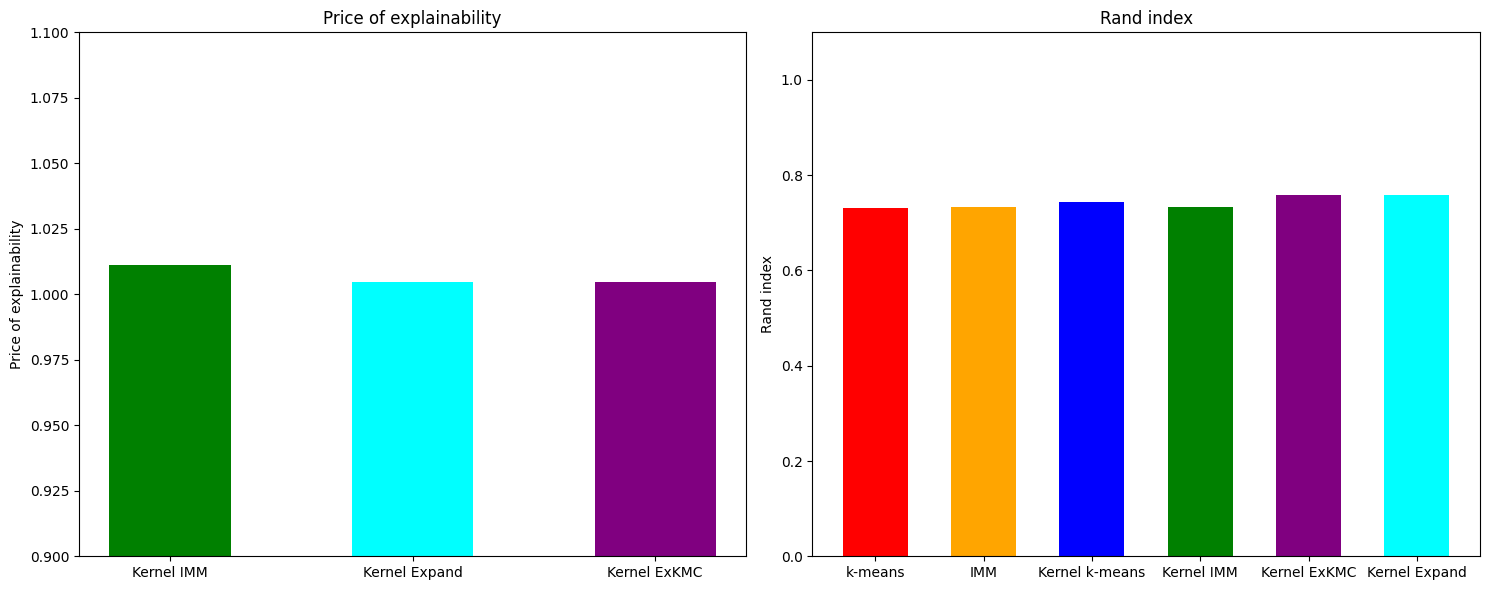

In [20]:
price_values = [price_imm, refine_iris1['price_expand'], refine_iris1['price_exkmc']]
rand_values = [imm_iris1['rand_kmeans'], imm_iris1['rand_imm'], imm_iris1['rand_kkm'], rand_imm, refine_iris1['rand_exkmc'], refine_iris1['rand_expand']]
plot_metric(price_values, rand_values)

In [21]:
X, y_true = load_dataset("Cancer")

gammas = 10**(-6)*np.array([1, 5, 10])
imm_wisc1, imm_wisc2 = imm_experiments(X, y_true, gammas)


--- First k-means
---> Rand Score of k-means: 0.49142453622455523
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0 1]
Cluster Label Partioning: [0] and [1]
Mistakes: 0
Cut node 0 at Coordinate 20 Threshold 19.575 ---> Mistakes = 0
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0]
... This is already a Leaf
--- Check node 1 ---
Node 1 contains cluster labels [1]
... This is already a Leaf
+++ IMM has finished +++
---> Rand Score of linear IMM: 0.49142453622455523
--- Now to kernels. Find kernel and gamma ---
Test Gamma = 1e-06
Test Gamma = 4.9999999999999996e-06
Test Gamma = 9.999999999999999e-06
We choose the <function rbf at 0x10e9c3f60> kernel with gamma = 4.9999999999999996e-06
--- Run kernel k-means ---
---> Rand Score: 0.6644358175948254
Run Gaussian Taylor IMM on kernel k-means
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0 1]
Cluster Label Partioning: [0] and [1]
Mistakes: 4
Cut node 0 at Coordinate 115 Threshol

In [22]:
y_kkm = imm_wisc2['y_kkm']
gamma = imm_wisc1['best_gamma']

if imm_wisc1['best_kernel'] == 0:
    Kmat = pairwise_kernels(X, metric=rbf, gamma=gamma)
    if imm_wisc1['price_taylor_imm_on_kkm'] < imm_wisc1['price_kmat_imm_on_kkm']:
        print('Gaussian Taylor')
        y_imm = imm_wisc2['y_taylor_imm_on_kkm']
        price_imm = imm_wisc1['price_taylor_imm_on_kkm']
        rand_imm = imm_wisc1['rand_taylor_imm_on_kkm']
    else:
        print('Gaussian Kernel Matrix')
        y_imm = imm_wisc2['y_kmat_imm_on_kkm']
        price_imm = imm_wisc1['price_kmat_imm_on_kkm']
        rand_imm = imm_wisc1['rand_kmat_imm_on_kkm']
else:
    print('Laplace Kernel Matrix')
    Kmat = pairwise_kernels(X, metric=laplace, gamma=gamma)
    y_imm = imm_wisc2['y_kmat_imm_on_kkm']
    price_imm = imm_wisc1['price_kmat_imm_on_kkm']
    rand_imm = imm_wisc1['rand_kmat_imm_on_kkm']

refine_wisc1, refine_wisc2 = refine_imm(X, y_true, y_kkm, y_imm, Kmat, max_leaves = 4)

Gaussian Kernel Matrix
Kernel ExKMC
+++ Currently, we have 2 node(s). Let us find a new cut! +++
--- Check node 0 ---
Number of points at this node: 176
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
Check Coordinate 2
Check Coordinate 3
Check Coordinate 4
Check Coordinate 5
Check Coordinate 6
Check Coordinate 7
Check Coordinate 8
Check Coordinate 9
Check Coordinate 10
Check Coordinate 11
Check Coordinate 12
Check Coordinate 13
Check Coordinate 14
Check Coordinate 15
Check Coordinate 16
Check Coordinate 17
Check Coordinate 18
Check Coordinate 19
Check Coordinate 20
Check Coordinate 21
Check Coordinate 22
Check Coordinate 23
Check Coordinate 24
Check Coordinate 25
Check Coordinate 26
Check Coordinate 27
Check Coordinate 28
Check Coordinate 29
---> Delta =  0.0
--- Check node 1 ---
Number of points at this node: 393
Available info at this node: Empty
Fetch info on this new node
Check Coordinate 0
Check Coordinate 1
Check Coordinate 2


In [23]:
print(imm_wisc1, refine_wisc1)

{'rand_kmeans': 0.49142453622455523, 'rand_imm': 0.49142453622455523, 'best_kernel': np.int64(0), 'best_gamma': np.float64(4.9999999999999996e-06), 'rand_kkm': 0.6644358175948254, 'rand_taylor_imm_on_kkm': 0.6758757704531635, 'price_taylor_imm_on_kkm': np.float64(1.0017943409252132), 'rand_kmat_imm_on_kkm': 0.6758757704531635, 'price_kmat_imm_on_kkm': np.float64(1.0017943409252132), 'threshold_cuts_taylor': array([[0.00000000e+00, 1.15000000e+02, 1.61634851e-02]]), 'threshold_cuts_kmat': array([[0.0000000e+00, 1.3108000e+04, 1.7194123e-01]])} {'rand_exkmc': 0.6758757704531635, 'price_exkmc': np.float64(1.0017943409252132), 'rand_expand': 0.670197680502722, 'price_expand': np.float64(1.0003628434824698)}


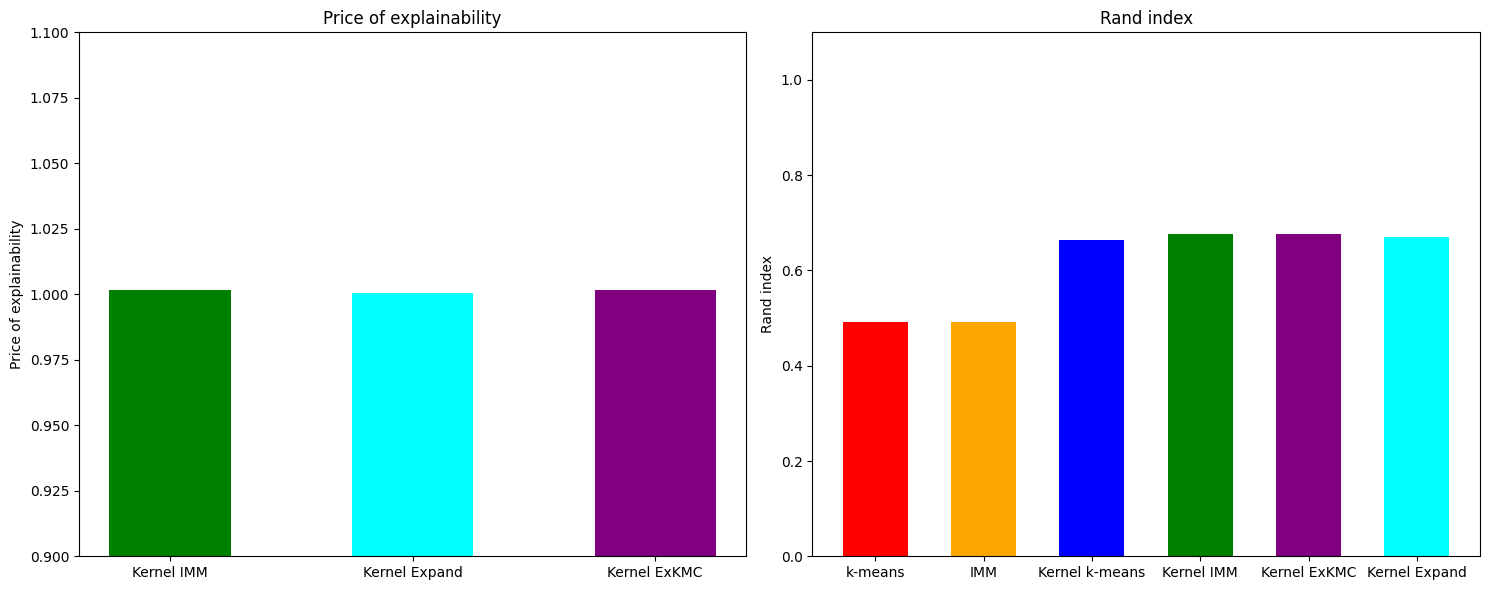

In [24]:
price_values = [price_imm, refine_wisc1['price_expand'], refine_wisc1['price_exkmc']]
rand_values = [imm_wisc1['rand_kmeans'], imm_wisc1['rand_imm'], imm_wisc1['rand_kkm'], rand_imm, refine_wisc1['rand_exkmc'], refine_wisc1['rand_expand']]
plot_metric(price_values, rand_values)

# Comparison: features_per_dim Analysis

Test and compare the impact of different `features_per_dim` values (1, 5, 20, 28) on Taylor IMM performance across all datasets.

In [25]:
from sklearn.metrics.cluster import adjusted_rand_score
from kernel_imm import taylor_imm
from kernel_kmeans import kernelkmeans, kernelkmeanscost

def test_features_per_dim(X, y_true, gamma, features_per_dim_values=[1, 5, 20, 35]):
    """Test different features_per_dim values and return results"""
    true_k = len(np.unique(y_true))
    
    # Run kernel k-means once
    Kmat = pairwise_kernels(X, metric=rbf, gamma=gamma)
    y_kkm = kernelkmeans(Kmat, true_k, algo='kernelkmeans', n_init=10, n_iter=200)
    
    results = []
    
    for fpd in features_per_dim_values:
        print(f'Testing features_per_dim = {fpd}')
        
        # Run Taylor IMM with different features_per_dim
        y_taylor_imm, threshold_cuts = taylor_imm(X, y_kkm, gamma, fpd, check_all_cuts=True)
        
        # Calculate metrics
        rand_score = adjusted_rand_score(y_taylor_imm, y_true)
        price = np.sum(kernelkmeanscost(Kmat, y_taylor_imm)) / np.sum(kernelkmeanscost(Kmat, y_kkm))
        num_cuts = len(threshold_cuts)
        
        results.append({
            'features_per_dim': fpd,
            'rand_score': rand_score,
            'price': price,
            'num_cuts': num_cuts
        })
        
        print(f'  Rand Score: {rand_score:.4f}, Price: {price:.4f}, Cuts: {num_cuts}')
    
    return results


In [26]:
# Test all datasets
datasets_config = [
    ('Pathbased', 0.05),
    ('Aggregation', 0.1),
    ('Flame', 0.05),
]

all_results = {}

for dataset_name, gamma_val in datasets_config:
    print(f'\n{"="*60}')
    print(f'Testing {dataset_name} dataset (gamma={gamma_val})')
    print(f'{"="*60}')
    
    X, y_true = load_dataset(dataset_name)
    results = test_features_per_dim(X, y_true, gamma_val)
    all_results[dataset_name] = results

print("\n✓ All tests completed!")


Testing Pathbased dataset (gamma=0.05)
Testing features_per_dim = 1
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0 1 2]
Cluster Label Partioning: [0] and [1 2]
Mistakes: 57
Cut node 0 at Coordinate 0 Threshold 1.3323883159600328e-08 ---> Mistakes = 57
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0]
... This is already a Leaf
--- Check node 1 ---
Node 1 contains cluster labels [1 2]
Cluster Label Partioning: [2] and [1]
Mistakes: 28
Cut node 1 at Coordinate 0 Threshold 0.02875795938312392 ---> Mistakes = 28
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0]
... This is already a Leaf
--- Check node 1 ---
Node 1 contains cluster labels [2]
... This is already a Leaf
--- Check node 2 ---
Node 2 contains cluster labels [1]
... This is already a Leaf
+++ IMM has finished +++
  Rand Score: 0.4545, Price: 1.0719, Cuts: 2
Testing features_per_dim = 5
+++ New Cut +++
--- Check node 0 ---
Node 0 contains cluster labels [0 1 2]

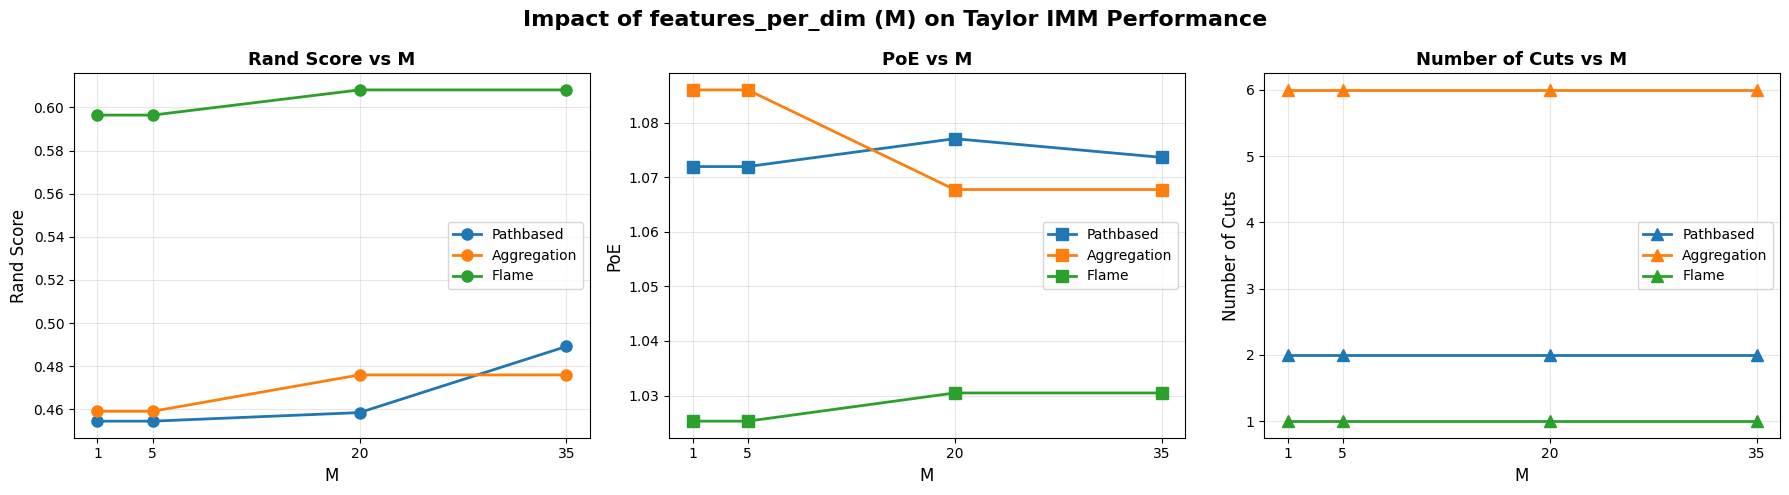

In [27]:
# Visualization: Comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Impact of features_per_dim (M) on Taylor IMM Performance', fontsize=16, fontweight='bold')

datasets = list(all_results.keys())
features_per_dim_vals = [1, 5, 20, 35]

# Plot 1: Rand Score comparison
ax1 = axes[0]
for dataset in datasets:
    results = all_results[dataset]
    rand_scores = [r['rand_score'] for r in results]
    ax1.plot(features_per_dim_vals, rand_scores, marker='o', linewidth=2, markersize=8, label=dataset)

ax1.set_xlabel('M', fontsize=12)
ax1.set_ylabel('Rand Score', fontsize=12)
ax1.set_title('Rand Score vs M', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(features_per_dim_vals)

# Plot 2: Price comparison
ax2 = axes[1]
for dataset in datasets:
    results = all_results[dataset]
    prices = [r['price'] for r in results]
    ax2.plot(features_per_dim_vals, prices, marker='s', linewidth=2, markersize=8, label=dataset)

ax2.set_xlabel('M', fontsize=12)
ax2.set_ylabel('PoE', fontsize=12)
ax2.set_title('PoE vs M', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(features_per_dim_vals)

# Plot 3: Number of cuts comparison
ax3 = axes[2]
for dataset in datasets:
    results = all_results[dataset]
    num_cuts = [r['num_cuts'] for r in results]
    ax3.plot(features_per_dim_vals, num_cuts, marker='^', linewidth=2, markersize=8, label=dataset)

ax3.set_xlabel('M', fontsize=12)
ax3.set_ylabel('Number of Cuts', fontsize=12)
ax3.set_title('Number of Cuts vs M', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xticks(features_per_dim_vals)

plt.tight_layout()
plt.show()

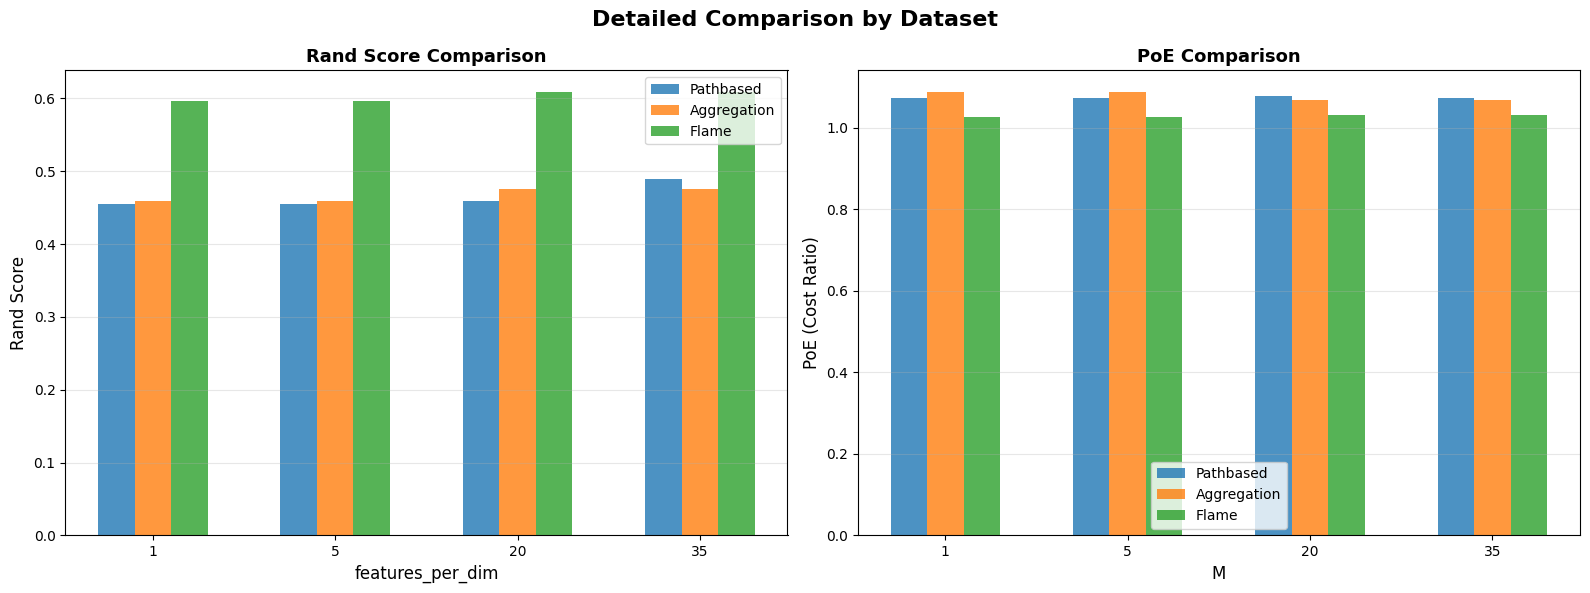

In [28]:
# Additional visualization: Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Detailed Comparison by Dataset', fontsize=16, fontweight='bold')

width = 0.2
x = np.arange(len(features_per_dim_vals))

# Plot 1: Grouped bar chart for Rand Score
ax1 = axes[0]
for i, dataset in enumerate(datasets):
    results = all_results[dataset]
    rand_scores = [r['rand_score'] for r in results]
    ax1.bar(x + i*width, rand_scores, width, label=dataset, alpha=0.8)

ax1.set_xlabel('features_per_dim', fontsize=12)
ax1.set_ylabel('Rand Score', fontsize=12)
ax1.set_title('Rand Score Comparison', fontsize=13, fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(features_per_dim_vals)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Grouped bar chart for Price
ax2 = axes[1]
for i, dataset in enumerate(datasets):
    results = all_results[dataset]
    prices = [r['price'] for r in results]
    ax2.bar(x + i*width, prices, width, label=dataset, alpha=0.8)

ax2.set_xlabel('M', fontsize=12)
ax2.set_ylabel('PoE (Cost Ratio)', fontsize=12)
ax2.set_title('PoE Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(x + width)
ax2.set_xticklabels(features_per_dim_vals)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [29]:
# Summary table
print("="*80)
print("SUMMARY: M Comparison Results")
print("="*80)

# Debug: print what datasets and values we have
print(f"\nDebug - Datasets in all_results: {list(all_results.keys())}")
print(f"Debug - M values: {[1, 5, 20, 35]}\n")

for dataset in datasets:
    print(f"\n{dataset} Dataset:")
    print("-" * 70)
    print(f"{'M':<20} {'Rand Score':<15} {'PoE':<15} {'Num Cuts':<10}")
    print("-" * 70)
    
    # Get results for THIS dataset
    dataset_results = all_results[dataset]
    
    for r in dataset_results:
        print(f"{r['features_per_dim']:<20} {r['rand_score']:<15.4f} {r['price']:<15.4f} {r['num_cuts']:<10}")
    
    # Find best configuration from THIS dataset's results
    best_rand = max(dataset_results, key=lambda x: x['rand_score'])
    best_price = min(dataset_results, key=lambda x: x['price'])
    
    print("-" * 70)
    print(f"Best Rand Score: M={best_rand['features_per_dim']} (Score={best_rand['rand_score']:.4f})")
    print(f"Best PoE: M={best_price['features_per_dim']} (PoE={best_price['price']:.4f})")

print("\n" + "="*80)

SUMMARY: M Comparison Results

Debug - Datasets in all_results: ['Pathbased', 'Aggregation', 'Flame']
Debug - M values: [1, 5, 20, 35]


Pathbased Dataset:
----------------------------------------------------------------------
M                    Rand Score      PoE             Num Cuts  
----------------------------------------------------------------------
1                    0.4545          1.0719          2         
5                    0.4545          1.0719          2         
20                   0.4585          1.0770          2         
35                   0.4892          1.0736          2         
----------------------------------------------------------------------
Best Rand Score: M=35 (Score=0.4892)
Best PoE: M=1 (PoE=1.0719)

Aggregation Dataset:
----------------------------------------------------------------------
M                    Rand Score      PoE             Num Cuts  
----------------------------------------------------------------------
1                  